Paquetes necesarios

In [2]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

**TAREA 1**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

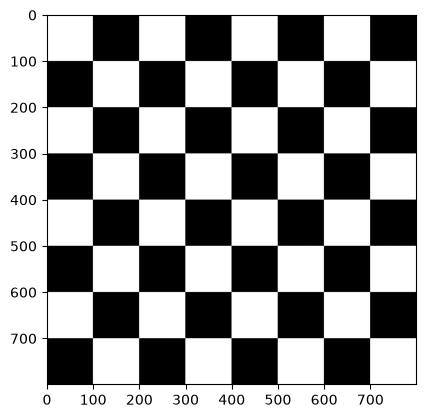

In [18]:
# Crea imagen vacía
chess_img = np.zeros((800,800,1), dtype = np.uint8)

# Recorre la imagen y pinta los cuadros blancos
for y in range(0, 800, 100):
    for x in range(0, 800, 200):
        if (y/100)%2==0 :
            chess_img[y:y+100, x:x+100] = 255
        else:
            chess_img[y:y+100, x+100:x+200] = 255

# Muestre la imagen resultante
plt.imshow(chess_img, cmap='gray',vmin=0, vmax=255)
plt.show()

Respuesta de la IA

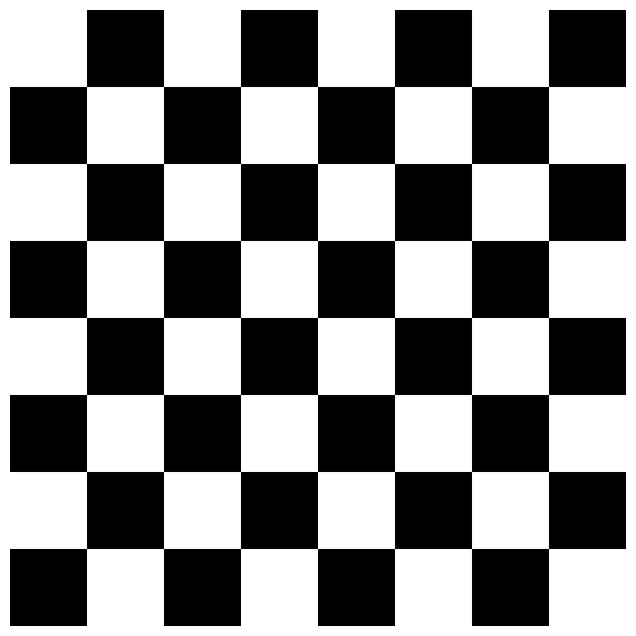

In [4]:
# Tamaño de la imagen
alto = 800
ancho = 800

# Número de casillas por lado
n = 8

# Tamaño de cada casilla
tam_casilla = alto // n

# Crear imagen vacía
tablero = np.zeros((alto, ancho, 3), dtype=np.uint8)

# Dibujar las casillas
for fila in range(n):
    for columna in range(n):

        # Alternar entre blanco y negro
        if (fila + columna) % 2 == 0:
            color = (255, 255, 255)  # Blanco
        else:
            color = (0, 0, 0)        # Negro

        # Coordenadas de la casilla
        x1 = columna * tam_casilla
        y1 = fila * tam_casilla
        x2 = x1 + tam_casilla
        y2 = y1 + tam_casilla

        # Dibujar rectángulo
        cv2.rectangle(tablero, (x1, y1), (x2, y2), color, -1)

# Mostrar el tablero
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(tablero, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

**TAREA 2**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

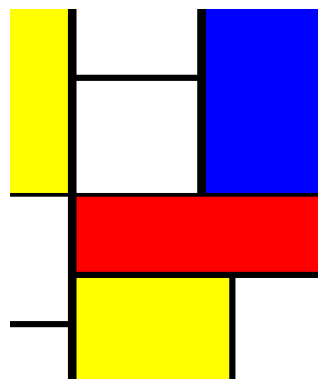

In [ ]:
# Tamaño de la imagen
ancho = 250
alto = 300

# Crea imagen vacía
mondrian_img = np.zeros((alto, ancho, 3), dtype=np.uint8)

# Transforma la imagen a blanca
mondrian_img[:,:,0] = 255
mondrian_img[:,:,1] = 255
mondrian_img[:,:,2] = 255

# Dibuja los rectángulos
cv2.rectangle(mondrian_img, (0,0), (50,150), (255, 255, 0), -1)
cv2.rectangle(mondrian_img, (50,150), (ancho,215), (255, 0, 0), -1)
cv2.rectangle(mondrian_img, (155,0), (ancho,150), (0, 0, 255), -1)
cv2.rectangle(mondrian_img, (50,215), (180,alto), (255, 255, 0), -1)

# Dibuja líneas verticales
cv2.line(mondrian_img, (50,0), (50,alto), (0, 0, 0), 5)
cv2.line(mondrian_img, (155,0), (155,148), (0, 0, 0), 5)
cv2.line(mondrian_img, (180,215), (180,alto), (0, 0, 0), 4)

# Dibuja líneas horizontales
cv2.line(mondrian_img, (0,150), (ancho,150), (0, 0, 0), 2)
cv2.line(mondrian_img, (50,215), (ancho,215), (0, 0, 0), 3)
cv2.line(mondrian_img, (50,55), (155,55), (0, 0, 0), 3)
cv2.line(mondrian_img, (0,255), (50,255), (0, 0, 0), 3)

#Muestra la imagen
plt.imshow(mondrian_img)
plt.axis("off")
plt.show()

**TAREA 3**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


In [ ]:
def max_and_min_px(h, w):
    # Variables globales con las posiciones 
    global min_pos, max_pos

    # Primer píxel como referencia para comparar
    min_pix = (int(frame[0, 0, 0]) + int(frame[0, 0, 1]) + int(frame[0, 0, 2]))
    max_pix = (int(frame[0, 0, 0]) + int(frame[0, 0, 1]) + int(frame[0, 0, 2]))

    # Recorre el frame
    for y in range(h):
        for x in range(w):

            # Valor del píxel
            pix = (int(frame[y, x, 0]) + int(frame[y, x, 1]) + int(frame[y, x, 2]))

            # Comparación para actualizar el max y min
            if pix > max_pix:
                max_pix = pix
                max_pos = (x, y)
            elif pix < min_pix:
                min_pix = pix
                min_pos = (x, y)


In [ ]:
vid = cv2.VideoCapture(0)
  
while True:      
    # Fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        # Dimensiones del fotograma
        h, w, c = frame.shape

        # Llamada a la función para el píxel con el máximo y mínimo valor
        max_and_min_px(h, w)

        # Dibuja círculos en las coordenadas dadas
        cv2.circle(frame, max_pos, 5, (0,0,255), -1)
        cv2.circle(frame, min_pos, 5, (255,0,0), -1)
        
        # Muestra fotograma
        cv2.imshow('Cam', frame)
    
    # Detiene pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

Usando funciones de OpenCV

In [ ]:
vid = cv2.VideoCapture(0)

while True:
    # Fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        # Transforma el frame a escalada de grises con 1 canal
        scale_grey = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Calcula el píxel de menor y mayor valor junto con sus posiciones
        min_pix, max_pix, min_pos, max_pos = cv2.minMaxLoc(scale_grey)

        # Dibuja círculos en las coordenadas dadas
        cv2.circle(frame, max_pos, 5, (0, 0, 255), -1)
        cv2.circle(frame, min_pos, 5, (255, 0, 0), -1)

        # Muestra fotograma
        cv2.imshow('Cam', frame)

    # Detiene pulsado ESC
    if cv2.waitKey(20) == 27:
        break

# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

**TAREA 4**: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

In [ ]:
vid = cv2.VideoCapture(0)

# Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Mitad de resolución para ocupar menos pantalla
w=int(w/2)
h=int(h/2)

#Imagen conjunta 2x original
popart = np.zeros((h*2,w*2,3), dtype = np.uint8)
tl = popart[0:h,0:w]
tr = popart[0:h,w:w+w] 
bl = popart[h:h+h,0:w] 
br = popart[h:h+h,w:w+w] 

while True:      
    # Fotograma a fotograma
    ret, frameIN = vid.read()

    #Menor tamaño
    frame = cv2.resize(frameIN, (int(w),int(h)),cv2.INTER_NEAREST)

    if ret:
        # Separa canales
        b = frame[:,:,0]
        g = frame[:,:,1]
        r = frame[:,:,2]

        # Plano arriba izquierda
        tl[0:int(h/2),0:int(w/2),0] = 255
        tl[0:int(h/2),0:int(w/2),2] = g[0:int(h/2),0:int(w/2)]
        tl[0:int(h/2),0:int(w/2),1] = 255 -r[0:int(h/2),0:int(w/2)]

        tl[0:int(h/2),int(w/2):w,0] = 255 
        tl[0:int(h/2),int(w/2):w,2] = r[0:int(h/2),int(w/2):w]
        tl[0:int(h/2),int(w/2):w,1] = b[0:int(h/2),int(w/2):w]

        tl[int(h/2):h,0:int(w/2),0] = 255
        tl[int(h/2):h,0:int(w/2),2] = r[int(h/2):h,0:int(w/2)]
        tl[int(h/2):h,0:int(w/2),1] = b[int(h/2):h,0:int(w/2)]

        tl[int(h/2):h,int(w/2):w,0] = 255
        tl[int(h/2):h,int(w/2):w,2] = g[int(h/2):h,int(w/2):w]
        tl[int(h/2):h,int(w/2):w,1] = 255 - r[int(h/2):h,int(w/2):w]

        # Plano arriba derecha
        tr[:,:,0] = 255 - r
        tr[:,:,1] = cv2.flip(g, 1)
        tr[:,:,2] = b
        
        # Plano abajo izquierda
        bl[:,:,0] = r
        bl[:,:,1] = 255 - b
        bl[:,:,2] = g

        for y in range(10, h, 20):
            for x in range(10, w, 20):
                if x < 50 or x >= w - 40 or y < 50 or y >= h - 40:
                    cv2.circle(bl, (x, y), 2, (0, 255, 255), -1)

        # Plano abajo derecha
        for y in range(h):
            for x in range(w):
                diagonal = x - y
                if diagonal < -50:
                    br[y, x] = (255, 50, r[y, x])
                elif diagonal < 180:
                    br[y, x] = (255 - r[y, x], g[y, x], 255)
                else:
                    br[y, x] = (50, 255, max(0, 180 - int(r[y, x])))

        # Muestra composición
        cv2.imshow('Cam', popart)
    
    # Detiene pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()